In [ ]:
!pip install qiskit
!pip install qiskit-ibm-runtime
!pip install pylatexenc
!pip install qiskit-aer
!pip install qiskit-algorithms
!pip install qiskit-nature
!pip install qiskit -machine-learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.

In [ ]:
from qiskit.providers.basic_provider import basic_simulator

In [ ]:
!pip install qiskit qiskit-aer matplotlib -q


In [ ]:
# library imports
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator #(simulator import)
from qiskit.visualization import plot_histogram #(qml not requires mostly)
import matplotlib.pyplot as plt #(direct 'mpl' also Ok if taken care)

In [ ]:
# simplest package
!pip install qiskit-aer matplotlib pylatexenc -q
#modules
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [ ]:
!pip install qiskit-aer matplotlib -q

# Imports
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Deutsch-Jozsa oracle
def deutsch_jozsa_oracle(circuit, n, oracle_type='balanced'):
    """Oracle creation for constant or balanced function"""

    if oracle_type == 'balanced':
        circuit.cx(0, n)  # Flip output qubit based on input qubit
    else:
        pass  # Constant function: output remains unchanged


Deutsch-Jozsa Quantum Circuit:
     ┌───┐          ┌───┐   ┌─┐
q_0: ┤ H ├───────■──┤ H ├───┤M├
     ├───┤┌───┐  │  └┬─┬┘   └╥┘
q_1: ┤ H ├┤ H ├──┼───┤M├─────╫─
     ├───┤├───┤  │   └╥┘ ┌─┐ ║ 
q_2: ┤ H ├┤ H ├──┼────╫──┤M├─╫─
     ├───┤├───┤┌─┴─┐  ║  └╥┘ ║ 
q_3: ┤ X ├┤ H ├┤ X ├──╫───╫──╫─
     └───┘└───┘└───┘  ║   ║  ║ 
c: 3/═════════════════╩═══╩══╩═
                      1   2  0 


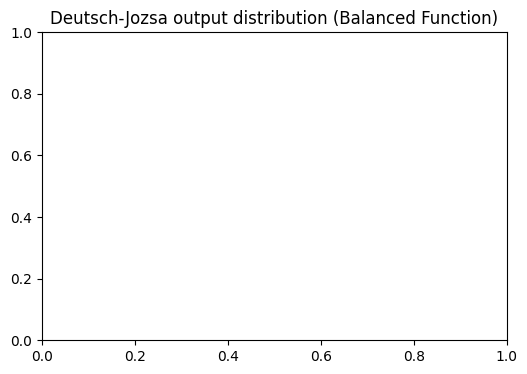

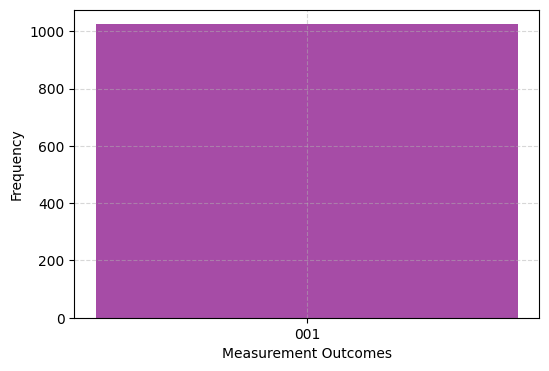

Function is BALANCED (non-zero outcomes detected.)


In [ ]:
def deutsch_jozsa_algorithm(n_qubits=3, oracle_type='balanced'):
    qc = QuantumCircuit(n_qubits + 1, n_qubits)

    # Here 5 steps are there

    # 1 - Initializing output qubit |1>
    qc.x(n_qubits)
    qc.h(n_qubits)

    # 2 - Hadamard on input qubits
    for i in range(n_qubits):
        qc.h(i)

    # 3 - Oracle application
    deutsch_jozsa_oracle(qc, n_qubits, oracle_type)

    # 4 - Hadamard 2nd time
    for i in range(n_qubits):
        qc.h(i)

    # 5 - Input measurement
    qc.measure(range(n_qubits), range(n_qubits))

    return qc


# D-J run
n_qubits = 3
oracle_type = 'balanced'  # whether constant / balanced?

qc = deutsch_jozsa_algorithm(n_qubits, oracle_type)

# Using AerSimulator
simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)

job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()


# OUTPUT 1 - Text Circuit
print("\nDeutsch-Jozsa Quantum Circuit:")
print(qc.draw('text'))


# OUTPUT 2 - Histogram
plt.figure(figsize=(6, 4))
plot_histogram(counts)
plt.title(
    f"Deutsch-Jozsa output distribution "
    f"({oracle_type.capitalize()} Function)"
)
plt.show()


# OUTPUT 3 - XAI-inspired Amplitude/Frequency graph
keys = list(counts.keys())
values = [counts[k] for k in keys]

plt.figure(figsize=(6, 4))
plt.bar(keys, values, color='purple', alpha=0.7)
plt.xlabel('Measurement Outcomes')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# OUTPUT 4 - Interpretation
if '000' in counts:
    print("Function is CONSTANT (all outcomes are zero.)")
else:
    print("Function is BALANCED (non-zero outcomes detected.)")

Measurement Results: {'11': 1024}


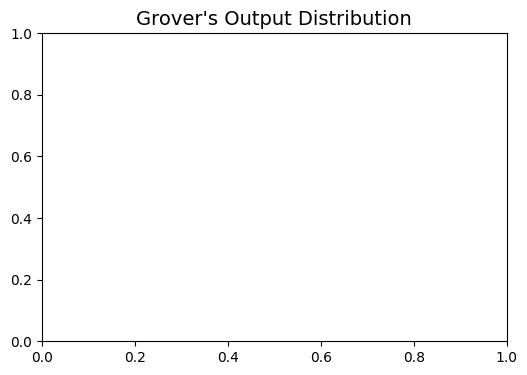

In [ ]:
!pip install qiskit-aer matplotlib -q

# Libraries
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Grover circuit
grover_circuit = QuantumCircuit(2, 2)  # 2 qubits

# Hadamard
grover_circuit.h([0, 1])

# Target marking / Oracle
grover_circuit.cz(0, 1)  # Oracle to mark |11>

# Amplitude amplification / Diffuser
grover_circuit.h([0, 1])
grover_circuit.x([0, 1])
grover_circuit.h(1)
grover_circuit.cx(0, 1)
grover_circuit.h(1)
grover_circuit.x([0, 1])
grover_circuit.h([0, 1])

# Measurement
grover_circuit.measure([0, 1], [0, 1])

# Simulation
simulator = AerSimulator()
job = simulator.run(grover_circuit, shots=1024)
result = job.result()
counts = result.get_counts()

# Output display
print("Measurement Results:", counts)

# Probability histogram
plt.figure(figsize=(6, 4))
plot_histogram(counts)
plt.title("Grover's Output Distribution", fontsize=14)
plt.show()

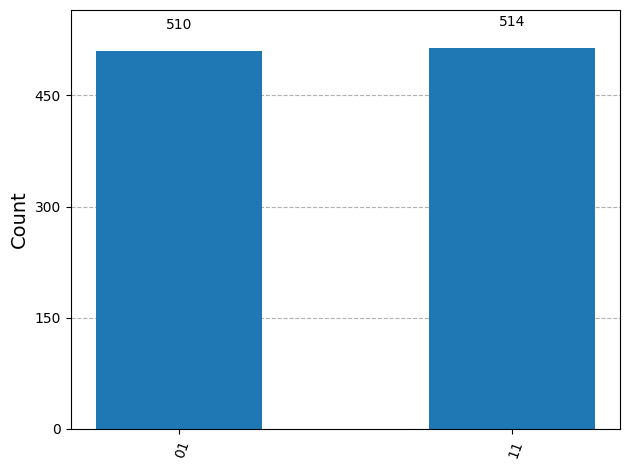

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

grover_circuit = QuantumCircuit(2,2)
grover_circuit.h([0,1])
grover_circuit.cz(0,1)
grover_circuit.h([0,1])
grover_circuit.x([0,1])
grover_circuit.h(1)
grover_circuit.cx(0,1)
grover_circuit.x([0,1])
grover_circuit.h([0,1])
grover_circuit.measure([0,1],[0,1])

simulator = AerSimulator()
job = simulator.run(grover_circuit, shots=1024)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

In [ ]:
!pip install qiskit-aer matplotlib -q
#libraries
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_visualization import plot_histogram
import matplotlib.pyplot as plt
#Grover cicuit
grover_circuit=QuantumCircuit(2,2)#2 qubit
grover_circuit.h([0,1])#Hadamard
#target marking
grover_circuit.cz(0,1)#oracle to mark ket{1}
#amplitude amplification(diffuser)
grover_circuit.h([0,1])
grover_circuit.x([0,1])
grover_circuit.h(1)
grover_circuit.cx(0,1)
grover_circuit.x([0,1])
grover_circuit.h([0,1])
# to measure
grover_circuit.measure([0,1],[0,1])
simulator=AerSimulator()# simulation run
job=simulator.run(grover_circuit,shots=1024)
result=job.result()
counts=result.get_counts()
#output display
print("Measurement Results:",counts)
#probability histogram
plt.figure(figsize=(6,4))
plot_histogram(counts)
plt.title("Grocer's output distribution",fontsize=14)
plt.show()

ModuleNotFoundError: No module named 'qiskit_visualization'

In [ ]:
!pip install numpy

In [ ]:
!pip install scipy

In [ ]:
!pip install QuantumInformation


In [ ]:
from QuantumInformation import QuantumMechanics as QM
Quantumobj=QM()


In [ ]:
import numpy as np

v_1 = np.array([
    1,
    complex(1, -1),
    complex(2, 3)
])

v_2 = np.array([
    2,
    complex(3, -1),
    complex(2, -3)
])

inn = Quantumobj.inner_product(v_1, v_2)

print(inn)

(1-10j)


In [ ]:
def inner_product(self, vec1, vec2):
    inn = complex(0.0, 0.0)

    assert len(vec1) == len(vec2), "Dimensions are not equal"

    for i in range(len(vec1)):
        inn = inn + np.conjugate(vec1[i]) * vec2[i]

    return inn

In [ ]:
print("Inner Product =", Quantumobj.inner_product(v_1, v_2))

Inner Product = (1-10j)


In [ ]:
def norm_vec(self, vec):
    norm = 0.0

    # For loop, calculating norm
    for i in range(len(vec)):
        norm = norm + abs(np.conjugate(vec[i]) * vec[i])

    return np.sqrt(norm)

In [ ]:
import numpy as np

v = np.array([
    1,
    complex(1, -1),
    complex(2, 3)
])

norm = Quantumobj.norm_vec(v)

print(norm)

4.0


In [ ]:
def normalization_vec(self, vec):
    norm = 0.0

    # Loop for calculation of ||v||
    for i in range(len(vec)):
        norm = norm + abs(np.conjugate(vec[i]) * vec[i])

    # Divide vector by its norm
    vec = vec / np.sqrt(norm)

    return vec

In [ ]:
v = np.array([
    1,
    complex(1, -1),
    complex(2, 3)
])

normalized_v = Quantumobj.normalization_vec(v)

print(normalized_v)

[0.25+0.j   0.25-0.25j 0.5 +0.75j]


In [ ]:
print(Quantumobj.norm_vec(normalized_v))

1.0


In [ ]:
def outer_product_rvec(self, vec1, vec2):
    matrix = np.zeros(
        (len(vec1), len(vec2)),
        dtype='complex128'
    )

    # Loop for outer product
    for i in range(len(vec1)):
        for j in range(len(vec2)):
            matrix[i, j] = vec1[i] * np.conjugate(vec2[j])

    return matrix

In [ ]:
import numpy as np

vec1 = np.array([1, 2])
vec2 = np.array([2, 3, 1])

matrix = Quantumobj.outer_product_rvec(vec1, vec2)

print(matrix)

[[2. 3. 1.]
 [4. 6. 2.]]


In [ ]:
# Qiskit version 1.0

from qiskit import QuantumCircuit
import numpy as np

# Classical encoding
v = np.array([1, 2, 3, 4], dtype=float)

# Normalization
norm = np.linalg.norm(v)
v_normalized = v / norm

# Quantum circuit creation
qc = QuantumCircuit(2)

# Encode into quantum state
qc.initialize(v_normalized, [0, 1])

# Display the quantum circuit
print("QuantumCircuit for vector encoding:")
print(qc)

# Add measurement
qc.measure_all()

# Qiskit simulation
from qiskit_aer import AerSimulator

simulator = AerSimulator()

# Simulate the defined circuit
result = simulator.run(qc, shots=1024).result()

# Get and display the result
counts = result.get_counts()

print("Simulation Result:", counts)

QuantumCircuit for vector encoding:
     ┌─────────────────────────────────────────────┐
q_0: ┤0                                            ├
     │  Initialize(0.18257,0.36515,0.54772,0.7303) │
q_1: ┤1                                            ├
     └─────────────────────────────────────────────┘
Simulation Result: {'01': 117, '00': 37, '10': 290, '11': 580}


In [ ]:
import cirq

# Create 2 qubits
q0, q1 = cirq.LineQubit.range(2)

# Circuit definition
circuit = cirq.Circuit(
    cirq.H(q0),
    cirq.CNOT(q0, q1),
    cirq.measure(q0, q1)
)

# Simulation of circuit
simulator = cirq.Simulator()
result = simulator.run(circuit)

print("Cirq Simulation Result:")
print(result)

Cirq Simulation Result:
q(0),q(1)=0, 0


In [ ]:
!pip install cirq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.7/733.7 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 110.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing instal

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 69.0 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1


In [ ]:
# Install first if needed:
# %pip install pennylane

import pennylane as qml

# Define a 2-qubit device
dev = qml.device("default.qubit", wires=2)

# Define quantum function
@qml.qnode(dev)
def circuit(params):
    qml.RY(params[0], wires=0)
    qml.RY(params[1], wires=1)
    qml.CNOT(wires=[0, 1])

    return qml.probs(wires=[0, 1])

# Execute the circuit with sample parameters
params = [0.5, 1.0]

print("PennyLane Simulation Result:")
print(circuit(params))

PennyLane Simulation Result:
[0.72301119 0.21578009 0.01406875 0.04713997]


In [ ]:
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
import numpy as np

# Define a feature mapping function
def feature_map(data_point):
    n_qubits = len(data_point)
    qc = QuantumCircuit(n_qubits)

    for i, feature in enumerate(data_point):
        qc.rz(feature, i)  # Z-rotation in proportion to feature value

    return qc


# Data point (example)
data_point = np.array([0.5, 1.0, 1.5])

# Feature map generation
qc = feature_map(data_point)

print("Quantum Circuit for Feature Mapping:")
print(qc)

# Draw the circuit
display(circuit_drawer(qc, output='mpl', style='iqp'))

ModuleNotFoundError: No module named 'qiskit'

In [ ]:
%pip install matplotlib pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.5 MB/s eta 0:00:00


In [ ]:
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
from IPython.display import display
import numpy as np

# Define a feature mapping function
def feature_map(data_point):
    n_qubits = len(data_point)
    qc = QuantumCircuit(n_qubits)

    for i, feature in enumerate(data_point):
        qc.rz(feature, i)

    return qc


# Data point
data_point = np.array([0.5, 1.0, 1.5])

# Feature map generation
qc = feature_map(data_point)

print("Quantum Circuit for Feature Mapping:")
print(qc)

# Draw the circuit
display(circuit_drawer(qc, output='mpl', style='iqp'))

ModuleNotFoundError: No module named 'qiskit'

In [ ]:
%pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 112.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.8 MB/s eta 0:00:00


In [ ]:
import qiskit
print(qiskit.__version__)

2.5.1


Quantum Circuit for Feature Mapping:
     ┌─────────┐
q_0: ┤ Rz(0.5) ├
     └┬───────┬┘
q_1: ─┤ Rz(1) ├─
     ┌┴───────┴┐
q_2: ┤ Rz(1.5) ├
     └─────────┘


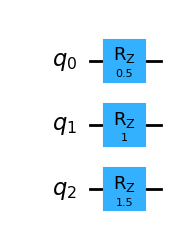

In [ ]:
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
from IPython.display import display
import numpy as np

# Define a feature mapping function
def feature_map(data_point):
    n_qubits = len(data_point)
    qc = QuantumCircuit(n_qubits)

    for i, feature in enumerate(data_point):
        qc.rz(feature, i)

    return qc

# Data point
data_point = np.array([0.5, 1.0, 1.5])

# Feature map generation
qc = feature_map(data_point)

print("Quantum Circuit for Feature Mapping:")
print(qc)

# Draw the circuit
display(circuit_drawer(qc, output='mpl', style='iqp'))

In [ ]:
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
import numpy as np

# Numerical features (Amplitude Encoding)
numerical_data = np.array([3, 2, 5, 7])

# Normalize numerical data
norm = np.linalg.norm(numerical_data)
normalized_numerical = numerical_data / norm

# Categorical features (Basis Encoding)
categorical_data = {
    "A": [0, 0],
    "B": [0, 1],
    "C": [1, 0]
}

category_state = categorical_data["B"]

# Creating Quantum Circuit
qc = QuantumCircuit(3)  # 2 qubits for numerical + 1 qubit for categorical

# Amplitude encoding
qc.initialize(normalized_numerical, [0, 1])

# Basis encoding
qc.initialize(category_state, 2)

print("Quantum Circuit for Hybrid Encoding:")
print(qc)

Quantum Circuit for Hybrid Encoding:
     ┌──────────────────────────────────────────────┐
q_0: ┤0                                             ├
     │  Initialize(0.32163,0.21442,0.53606,0.75048) │
q_1: ┤1                                             ├
     └─────────────┬─────────────────┬──────────────┘
q_2: ──────────────┤ Initialize(0,1) ├───────────────
                   └─────────────────┘               


In [ ]:
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 12.7 MB/s eta 0:00:00


In [ ]:
# Quantum Feature Map with Visualization

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap
from qiskit.visualization import circuit_drawer
from IPython.display import display


# Visualizing quantum circuit
def plot_quantum_circuit(qc):
    """Function to plot the quantum circuit"""
    print("\nQuantum Feature Map Circuit:")
    print(qc.decompose())

    display(
        circuit_drawer(
            qc,
            output='mpl',
            style={'backgroundcolor': 'white'}
        )
    )


# Define a quantum feature map
feature_map = ZZFeatureMap(
    feature_dimension=2,
    reps=2
)

# Visualize the feature map
plot_quantum_circuit(feature_map)


Quantum Feature Map Circuit:
     ┌───┐┌───────────┐                                        ┌───┐»
q_0: ┤ H ├┤ P(2*x[0]) ├──■──────────────────────────────────■──┤ H ├»
     ├───┤├───────────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐├───┤»
q_1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├┤ H ├»
     └───┘└───────────┘└───┘└────────────────────────────┘└───┘└───┘»
«     ┌───────────┐                                        
«q_0: ┤ P(2*x[0]) ├──■──────────────────────────────────■──
«     ├───────────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐
«q_1: ┤ P(2*x[1]) ├┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├
«     └───────────┘└───┘└────────────────────────────┘└───┘


/tmp/ipykernel_697/2733040313.py:28: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


MissingOptionalLibraryError: "The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'."

In [ ]:
%pip install pylatexenc

/tmp/ipykernel_2641/1268727800.py:31: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(



Quantum Feature Map Circuit:
     ┌───┐┌───────────┐                                        ┌───┐»
q_0: ┤ H ├┤ P(2*x[0]) ├──■──────────────────────────────────■──┤ H ├»
     ├───┤├───────────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐├───┤»
q_1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├┤ H ├»
     └───┘└───────────┘└───┘└────────────────────────────┘└───┘└───┘»
«     ┌───────────┐                                        
«q_0: ┤ P(2*x[0]) ├──■──────────────────────────────────■──
«     ├───────────┤┌─┴─┐┌────────────────────────────┐┌─┴─┐
«q_1: ┤ P(2*x[1]) ├┤ X ├┤ P(2*(π - x[0])*(π - x[1])) ├┤ X ├
«     └───────────┘└───┘└────────────────────────────┘└───┘


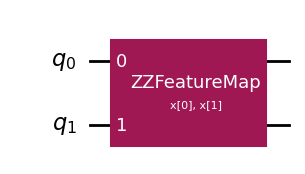

In [ ]:
# Install this once if needed:
# %pip install pylatexenc

# Quantum Feature Map with Visualization

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap
from qiskit.visualization import circuit_drawer
from IPython.display import display


# Visualizing quantum circuit
def plot_quantum_circuit(qc):
    """Function to plot the quantum circuit"""
    print("\nQuantum Feature Map Circuit:")
    print(qc.decompose())

    display(
        circuit_drawer(
            qc,
            output='mpl',
            style={'backgroundcolor': 'white'}
        )
    )


# Define a quantum feature map
feature_map = ZZFeatureMap(
    feature_dimension=2,
    reps=2
)

# Visualize the feature map
plot_quantum_circuit(feature_map)

In [ ]:
!pip install qiskit matplotlib numpy -q

In [ ]:
!pip install qiskit matplotlib numpy scipy -q

In [ ]:
%pip install pylatexenc

VQE Result:
----------------------------
Optimal Parameters:
[ 3.60526587e+00 -3.34093979e-05]

Minimum Energy:
-2.2360679762676754

Number of Iterations:
57

Optimized Quantum Circuit:
        ┌────────────┐       
q_0: ───┤ Ry(3.6053) ├────■──
     ┌──┴────────────┴─┐┌─┴─┐
q_1: ┤ Ry(-3.3409e-05) ├┤ X ├
     └─────────────────┘└───┘


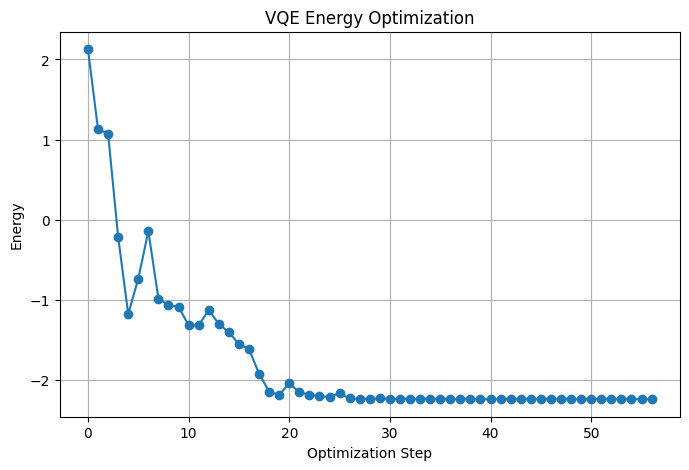

In [ ]:
# ============================================================
# VQE - Variational Quantum Eigensolver
# Google Colab / Qiskit
# ============================================================

# Install required packages
!pip install qiskit matplotlib numpy scipy -q


# ============================================================
# Imports
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp
from scipy.optimize import minimize


# ============================================================
# Define the Hamiltonian
# H = ZI + IZ + XX
# ============================================================

Hamiltonian = SparsePauliOp.from_list([
    ("ZI", 1.0),
    ("IZ", 1.0),
    ("XX", 1.0)
])


# ============================================================
# Define the variational quantum circuit (Ansatz)
# ============================================================

def ansatz(params):

    qc = QuantumCircuit(2)

    # Parameterized rotations
    qc.ry(params[0], 0)
    qc.ry(params[1], 1)

    # Entanglement
    qc.cx(0, 1)

    return qc


# ============================================================
# Calculate expectation value / energy
# ============================================================

def energy_function(params):

    # Create parameterized circuit
    qc = ansatz(params)

    # Convert circuit to statevector
    state = Statevector.from_instruction(qc)

    # Calculate <psi|H|psi>
    energy = np.real(
        state.expectation_value(Hamiltonian)
    )

    return energy


# ============================================================
# Initial parameters
# ============================================================

initial_params = np.array([0.5, 0.5])


# ============================================================
# Store energy values during optimization
# ============================================================

energy_history = []


def objective_function(params):

    energy = energy_function(params)

    # Store energy for plotting
    energy_history.append(energy)

    return energy


# ============================================================
# Classical optimizer
# ============================================================

result = minimize(
    objective_function,
    initial_params,
    method="COBYLA"
)


# ============================================================
# Display results
# ============================================================

print("VQE Result:")
print("----------------------------")

print("Optimal Parameters:")
print(result.x)

print("\nMinimum Energy:")
print(result.fun)

print("\nNumber of Iterations:")
print(result.nfev)


# ============================================================
# Display optimized quantum circuit
# ============================================================

optimal_circuit = ansatz(result.x)

print("\nOptimized Quantum Circuit:")
print(optimal_circuit)


# ============================================================
# Plot optimization process
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    energy_history,
    marker="o"
)

plt.xlabel("Optimization Step")
plt.ylabel("Energy")
plt.title("VQE Energy Optimization")

plt.grid()

plt.show()